In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


sys.version_info(major=3, minor=12, micro=10, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.2
pandas 3.0.0
sklearn 1.8.0
torch 2.6.0+cu124
cuda:0


In [2]:
from tensorflow import keras
imdb = keras.datasets.imdb
vocab_size = 10000
index_from = 3
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words = vocab_size, index_from = index_from)


D:\python3.12\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
word_index = imdb.get_word_index()
word2idx = {word: idx + 3 for word, idx in word_index.items()}
word2idx.update({
    "[PAD]": 0,     # 填充 token
    "[BOS]": 1,     # begin of sentence
    "[UNK]": 2,     # 未知 token
    "[EOS]": 3,     # end of sentence
})

idx2word = {idx: word for word, idx in word2idx.items()}


In [4]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx

    def encode(self, text_list, padding_first=False):
        max_length = min(self.max_length, 2 + max([len(text) for text in text_list]))
        indices_list = []
        for text in text_list:
            indices = [self.bos_idx] + [self.word2idx.get(word, self.unk_idx) for word in text[:max_length-2]] + [self.eos_idx]
            if padding_first:
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        return torch.tensor(indices_list)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]")
                if remove_bos and word == "[BOS]": continue
                if remove_eos and word == "[EOS]": break
                if remove_pad and word == "[PAD]": break
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list

tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)


In [5]:
from torch.utils.data import Dataset, DataLoader

class IMDBDataset(Dataset):
    def __init__(self, data, labels, remain_length=True):
        if remain_length:
            self.data = tokenizer.decode(data, remove_bos=False, remove_eos=False, remove_pad=False)
        else:
            self.data = tokenizer.decode(data)
        self.labels = labels

    def __getitem__(self, index):
        return self.data[index], self.labels[index]

    def __len__(self):
        return len(self.data)

def collate_fct(batch):
    text_list = [item[0].split() for item in batch]
    label_list = [item[1] for item in batch]
    # 单向 RNN 推荐 padding_first=True，这样最后一个时间步就是句子的结尾
    text_list = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)
    return text_list, torch.tensor(label_list).reshape(-1, 1).to(dtype=torch.float)

train_ds = IMDBDataset(train_data, train_labels, remain_length=False)
test_ds = IMDBDataset(test_data, test_labels, remain_length=False)

batch_size = 128
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fct)


In [6]:
class TwoLayerRNN(nn.Module):
    def __init__(self, embedding_dim=16, hidden_dim=64, vocab_size=vocab_size):
        super(TwoLayerRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # 设置 num_layers=2, bidirectional=False (默认)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=False)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: [bs, seq_len]
        x = self.embedding(x) # [bs, seq_len, embedding_dim]

        # seq_output: [bs, seq_len, hidden_dim]
        # final_hidden: [num_layers, bs, hidden_dim] -> [2, bs, hidden_dim]
        seq_output, final_hidden = self.rnn(x)

        # 对于单向 RNN 且 padding_first=True，最后一个时间步 seq_output[:, -1, :] 包含了整个句子的信息
        # 或者直接取最后一层的 final_hidden
        # x = final_hidden[-1, :, :]
        x = seq_output[:, -1, :]

        x = self.fc(x)
        return x

print("{:=^80}".format(" 双层单向 RNN "))
model = TwoLayerRNN()
for key, value in model.named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")


=================================== 双层单向 RNN ===================================
            embedding.weight            paramerters num: 160000
            rnn.weight_ih_l0            paramerters num: 1024
            rnn.weight_hh_l0            paramerters num: 4096
             rnn.bias_ih_l0             paramerters num: 64
             rnn.bias_hh_l0             paramerters num: 64
            rnn.weight_ih_l1            paramerters num: 4096
            rnn.weight_hh_l1            paramerters num: 4096
             rnn.bias_ih_l1             paramerters num: 64
             rnn.bias_hh_l1             paramerters num: 64
               fc.weight                paramerters num: 64
                fc.bias                 paramerters num: 1


In [7]:
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    model.eval()
    loss_list, pred_list, label_list = [], [], []
    for datas, labels in dataloader:
        datas, labels = datas.to(device), labels.to(device)
        logits = model(datas)
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())
        preds = (logits > 0).cpu().numpy()
        pred_list.extend(preds.tolist())
        label_list.extend(labels.cpu().numpy().tolist())
    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc


In [8]:
def training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=500):
    record_dict = {"train": [], "val": []}
    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            for datas, labels in train_loader:
                datas, labels = datas.to(device), labels.to(device)
                optimizer.zero_grad()
                logits = model(datas)
                loss = loss_fct(logits, labels)
                loss.backward()
                optimizer.step()

                preds = (logits > 0).cpu().numpy()
                acc = accuracy_score(labels.cpu().numpy(), preds)

                if global_step % eval_step == 0:
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({"loss": val_loss, "acc": val_acc, "step": global_step})
                    model.train()
                    print(f"\n[Step {global_step}] Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

                record_dict["train"].append({"loss": loss.item(), "acc": acc, "step": global_step})

                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id, "loss": f"{loss.item():.4f}", "acc": f"{acc:.4f}"})
    return record_dict


In [9]:
model = TwoLayerRNN().to(device)
loss_fct = F.binary_cross_entropy_with_logits
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 开始训练
record = training(model, train_dl, test_dl, epoch=10, loss_fct=loss_fct, optimizer=optimizer, eval_step=len(train_dl))


  0%|          | 0/1960 [00:00<?, ?it/s]


[Step 0] Val Loss: 0.6941, Val Acc: 0.5014

[Step 196] Val Loss: 0.6831, Val Acc: 0.5581

[Step 392] Val Loss: 0.6488, Val Acc: 0.6226

[Step 588] Val Loss: 0.6890, Val Acc: 0.5496

[Step 784] Val Loss: 0.6860, Val Acc: 0.5418

[Step 980] Val Loss: 0.6626, Val Acc: 0.5929

[Step 1176] Val Loss: 0.6470, Val Acc: 0.6238

[Step 1372] Val Loss: 0.6307, Val Acc: 0.6578

[Step 1568] Val Loss: 0.6954, Val Acc: 0.5661

[Step 1764] Val Loss: 0.6890, Val Acc: 0.5596


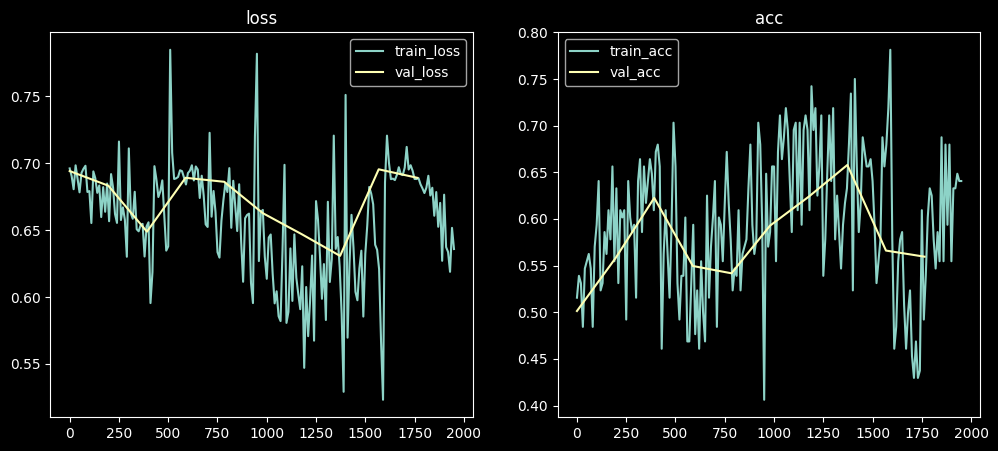

In [10]:
def plot_learning_curves(record_dict):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::10]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for i, col in enumerate(["loss", "acc"]):
        axs[i].plot(train_df.index, train_df[col], label=f"train_{col}")
        axs[i].plot(val_df.index, val_df[col], label=f"val_{col}")
        axs[i].legend()
        axs[i].set_title(col)
    plt.show()

plot_learning_curves(record)


In [11]:
# 最终在测试集上评估
print("{:=^80}".format(" 最终测试集评估 "))
test_loss, test_acc = evaluating(model, test_dl, loss_fct)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


=================================== 最终测试集评估 ====================================
Test Loss: 0.6903
Test Accuracy: 0.5407
